# T-SEA Targeted Adversarial Patch — YOLOv11 Pretrained on COCO

## Targeted Attack Strategy

| Original Class in Dataset | COCO ID (Pretrained) | Target Class (Misclassification) | COCO ID |
|---|---|---|---|
| person (label=1 → YOLO=1) | 0 | fire hydrant / parking meter | 10, 11 |
| car + truck + bus (label=2 → YOLO=0) | 2, 5, 7 | bench / traffic light | 13, 9 |

### Rationale for Target Selection
- **Person → fire hydrant / parking meter**: Both are vertical, cylindrical objects with similar height-to-width ratios to a human figure.
- **Vehicle → bench / traffic light**: Traffic lights frequently appear in the vicinity of vehicles; benches possess a horizontal shape geometrically similar to that of a vehicle.

### Class Mapping Note
```text
Custom Dataset:      car (JSON=1) → YOLO=0    person (JSON=2) → YOLO=1
YOLOv11 Pretrained:  person=0, car=2, bus=5, truck=7, 
                     traffic_light=9, fire_hydrant=10, parking_meter=11,
                     bench=13

In [1]:
!pip install ultralytics tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T_tv
import numpy as np
import json, zipfile, random, cv2, os, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.auto import tqdm
from ultralytics import YOLO
from PIL import Image as PIL_Image
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
print('✅ Imports OK')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB
✅ Imports OK


## ⚙️ CONFIG

In [50]:
# ================================================================
# STATIC CONFIG
# ================================================================
WORK_DIR      = '/kaggle/working/tsea_targeted_1cont'
DATASET_ROOT  = '/kaggle/input/datasets/bichhanhluuthi/my-dataset/My_Thesis_Dataset'
YOLO_DIR      = '/kaggle/working/yolo_dataset'   # Pre-generated from the previous notebook

# ── Pretrained YOLOv11 (80 class COCO) ──────────────────────────
# Use pretrained weights instead of fine-tuning to access out-of-dataset classes
PRETRAIN_WEIGHTS = 'yolo11m.pt'   # Automatically downloaded if not locally available

# ── Class mapping: Custom dataset → COCO pretrained ────────────
# Dataset: car=YOLO0, person=YOLO1
# COCO pretrained:
COCO_PERSON       = 0
COCO_VEHICLE      = [2, 5, 7]    # car=2, bus=5, truck=7
#   (The custom 'car' class aggregates car, truck, and bus → attack all three)

# ── Target classes (for misclassification) ───────────────────────
COCO_TARGET_PERSON  = [10, 11]   # fire_hydrant=10, parking_meter=11
COCO_TARGET_VEHICLE = [9, 13]    # traffic_light=9, bench=13

# ── Patch geometry ──────────────────────────────────────────────
PATCH_W        = 200
PATCH_H        = 200
PATCH_SCALE    = 0.40
PATCH_ANCHOR_Y = 0.35
MIN_PATCH_PX   = 16
IMG_SIZE       = 640

# ── Alpha blending ───────────────────────────────────────────────
PATCH_ALPHA    = 0.9   # 1.0 = complete override, 0.5 = mild blending

# ── Loss weights ─────────────────────────────────────────────────
TV_LAMBDA      = 0.005   # Total Variation (TV) weight for patch smoothness
# Targeted loss formulation: L = λ_src*conf_source - λ_tgt*conf_target + λ_tv*tv
LAMBDA_SOURCE  = 1.2    # Suppress the source class (decrease confidence for person/vehicle)
LAMBDA_TARGET  = 0.5    # Promote the target class (increase confidence for hydrant/bench)
TEXTURE_LAMBDA = 0.001
# If LAMBDA_TARGET = 0 → untargeted attack (similar to v1)
# If LAMBDA_TARGET > 0 → targeted attack

# ── Training ─────────────────────────────────────────────────────
LR_INIT          = 0.05
LR_DECAY_FACTOR  = 0.7
LR_PATIENCE      = 10
PATCH_PATIENCE   = 10
LR_MIN_DELTA     = 1e-3
LR_MIN           = 5e-4
BATCH_SIZE       = 16


N_EPOCHS         = 100
MAX_TRAIN_IMGS   = 900
MAX_VAL_IMGS     = 100
CONF_THRESHOLD   = 0.25
CHECKPOINT_EVERY = 5

# ── T-SEA ensemble ───────────────────────────────────────────────
SHAKEDROP_PROB = 0.5
SHAKEDROP_E    = 0.5
CUTOUT_PROB    = 0.5
CUTOUT_RATIO   = 0.30

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

for d in ['patches', 'checkpoints', 'results']:
    Path(WORK_DIR, d).mkdir(parents=True, exist_ok=True)

print('✅ Static config OK')

✅ Static config OK


In [51]:
# ================================================================
# EXPERIMENT CONFIG — Modify for each run
# ================================================================

# CLASS_MODE: 'person' or 'vehicle'
CLASS_MODE   = 'person'

VIDEO_TARGET = 'gostiny_dvor_001'   # 'universal' or a specific video name
METHOD       = 'tsea'

# INIT_PATCH_PATH: None = random initialization, or path to a .pt/.jpg texture file
INIT_PATCH_PATH = '/kaggle/working/tsea_targeted_1/patches/targeted_person_gostiny_dvor_001_best_filled.pt'

# ── Automatically configure source/target classes based on CLASS_MODE ─────────
if CLASS_MODE == 'person':
    # Dataset label: person = YOLO class 1
    DATASET_CLS    = 1                  # Class index in the custom YOLO label file
    SOURCE_CLASSES = [COCO_PERSON]      # [0] in the pretrained COCO model
    TARGET_CLASSES = COCO_TARGET_PERSON # [10, 11] fire_hydrant, parking_meter
    SOURCE_NAME    = 'person'
    TARGET_NAME    = 'fire_hydrant+parking_meter'
else:  # vehicle
    # Dataset label: car = YOLO class 0
    DATASET_CLS    = 0
    SOURCE_CLASSES = COCO_VEHICLE       # [2, 5, 7] car + bus + truck
    TARGET_CLASSES = COCO_TARGET_VEHICLE # [9, 13] traffic_light, bench
    SOURCE_NAME    = 'car+bus+truck'
    TARGET_NAME    = 'traffic_light+bench'

EXP_NAME = f'targeted_{CLASS_MODE}_{VIDEO_TARGET}'

print('=' * 60)
print(f'  Mode      : {CLASS_MODE.upper()} → {TARGET_NAME}')
print(f'  Source cls: {SOURCE_CLASSES} ({SOURCE_NAME})')
print(f'  Target cls: {TARGET_CLASSES} ({TARGET_NAME})')
print(f'  λ_source={LAMBDA_SOURCE}  λ_target={LAMBDA_TARGET}  λ_tv={TV_LAMBDA}')
print(f'  PATCH_ALPHA={PATCH_ALPHA}')
print('=' * 60)

  Mode      : PERSON → fire_hydrant+parking_meter
  Source cls: [0] (person)
  Target cls: [10, 11] (fire_hydrant+parking_meter)
  λ_source=1.2  λ_target=0.5  λ_tv=0.005
  PATCH_ALPHA=0.9


## 📦 Load Model (Pretrained COCO)

In [52]:
# ================================================================
# Load YOLOv11 pretrained COCO (80 class)
# ================================================================
yolo_wrapper = YOLO(PRETRAIN_WEIGHTS)
model        = yolo_wrapper.model
model.eval().to(DEVICE)

for p in model.parameters():
    p.requires_grad_(False)

print(f'✅ Model: {PRETRAIN_WEIGHTS}')

coco_names = yolo_wrapper.names
num_classes = len(coco_names)  

print(f'   Number of class: {num_classes}')
assert num_classes == 80, f'Cần pretrained 80 class! Hiện tại: {num_classes}'

print('\n  Verify class mapping:')
for cid in [0, 2, 5, 7, 9, 10, 11, 13, 17, 18, 19]:
    print(f'    COCO [{cid:2d}] = {coco_names[cid]}')

✅ Model: yolo11m.pt
   Số class: 80

  Verify class mapping:
    COCO [ 0] = person
    COCO [ 2] = car
    COCO [ 5] = bus
    COCO [ 7] = truck
    COCO [ 9] = traffic light
    COCO [10] = fire hydrant
    COCO [11] = stop sign
    COCO [13] = bench
    COCO [17] = horse
    COCO [18] = sheep
    COCO [19] = cow


## 📂 Load Dataset

In [6]:
import json, cv2, random, shutil
from pathlib import Path

DATASET_ROOT = '/kaggle/input/datasets/bichhanhluuthi/my-dataset/My_Thesis_Dataset'
YOLO_DIR     = '/kaggle/working/yolo_dataset'

CLASS_JSON2YOLO = {1: 0, 2: 1}  # Class mapping from JSON to YOLO format: car=1→0, person=2→1

ALL_VIDEOS = [
    'annichkov_most_001', 'annichkov_most_002',
    'dvorzovy_most_001',
    'gostiny_dvor_001',   'gostiny_dvor_002',
    'zagorodny_proezd_001'
]

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15 

SEED = 42
random.seed(SEED)

# Create directory structure for each data split
for split in ['train', 'val', 'test'] + [f'test_{v}' for v in ALL_VIDEOS]:
    Path(YOLO_DIR, 'images', split).mkdir(parents=True, exist_ok=True)
    Path(YOLO_DIR, 'labels', split).mkdir(parents=True, exist_ok=True)

print('✅ Directory structure created successfully')

total_train = total_val = total_test = 0
total_skip  = 0

for video_name in ALL_VIDEOS:
    ann_path = Path(DATASET_ROOT) / 'annotations' / f'{video_name}.json'
    img_dir  = Path(DATASET_ROOT) / 'images' / video_name

    print(f'\n{video_name}')

    with open(ann_path) as f:
        coco = json.load(f)

    # Build image ID to filename mapping
    id2fname = {img['id']: img['file_name'] for img in coco['images']}

    # Build image ID to bounding boxes mapping (YOLO normalized format)
    id2boxes = {}
    for ann in coco['annotations']:
        cid = ann['category_id']
        if cid not in CLASS_JSON2YOLO:
            continue
        yc = CLASS_JSON2YOLO[cid]
        iid = ann['image_id']

        img_info = next((x for x in coco['images'] if x['id'] == iid), None)
        if img_info is None:
            continue
        iw, ih = img_info['width'], img_info['height']

        x, y, w, h = ann['bbox']
        cx = (x + w/2) / iw
        cy = (y + h/2) / ih
        nw = w / iw
        nh = h / ih
        cx = max(0.001, min(0.999, cx))
        cy = max(0.001, min(0.999, cy))
        nw = max(0.001, min(1.0,   nw))
        nh = max(0.001, min(1.0,   nh))

        id2boxes.setdefault(iid, []).append((yc, cx, cy, nw, nh))

    # Filter only images with valid annotations
    valid_ids = [iid for iid in id2boxes if id2boxes[iid]]

    # Sort by image ID (chronological order) before shuffling
    valid_ids = sorted(valid_ids)
    random.shuffle(valid_ids)

    n       = len(valid_ids)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        'train': valid_ids[:n_train],
        'val'  : valid_ids[n_train : n_train + n_val],
        'test' : valid_ids[n_train + n_val:]
    }

    print(f'  Total: {n} | train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')

    for split_name, ids in splits.items():
        skip = 0
        for iid in ids:
            fname = Path(id2fname[iid])

            # Locate the actual image file (handle extension mismatches, e.g., JSON specifies .png but actual is .jpg)
            img_path = None
            for ext in [fname.name,
                        fname.with_suffix('.jpg').name,
                        fname.with_suffix('.png').name]:
                p = img_dir / ext
                if p.exists():
                    img_path = p
                    break

            if img_path is None:
                skip += 1
                continue

            # Output filename format: {video}_{frame_stem}.jpg
            out_stem = f'{video_name}_{img_path.stem}'
            out_img  = Path(YOLO_DIR, 'images', split_name, out_stem + '.jpg')
            out_lbl  = Path(YOLO_DIR, 'labels', split_name, out_stem + '.txt')

            # Copy and convert the image
            if not out_img.exists():
                bgr = cv2.imread(str(img_path))
                if bgr is None:
                    skip += 1
                    continue
                cv2.imwrite(str(out_img), bgr)

            # Write the YOLO label file
            if not out_lbl.exists():
                with open(out_lbl, 'w') as f:
                    for (yc, cx, cy, nw, nh) in id2boxes[iid]:
                        f.write(f'{yc} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n')

            # If the current split is 'test', also copy to the video-specific test directory (test_{video})
            if split_name == 'test':
                out_img2 = Path(YOLO_DIR, 'images', f'test_{video_name}', out_stem + '.jpg')
                out_lbl2 = Path(YOLO_DIR, 'labels', f'test_{video_name}', out_stem + '.txt')
                if not out_img2.exists():
                    shutil.copy2(out_img, out_img2)
                if not out_lbl2.exists():
                    shutil.copy2(out_lbl, out_lbl2)

        if skip > 0:
            print(f'  ⚠️  {split_name}: skipped {skip} images due to missing files')

    total_train += len(splits['train'])
    total_val   += len(splits['val'])
    total_test  += len(splits['test'])

# Final statistics
print('\n' + '='*50)
print(f'✅ COMPLETED')
print(f'   Train : {total_train} images')
print(f'   Val   : {total_val}   images')
print(f'   Test  : {total_test}  images (+ copied to test_<video>/)')
print(f'   Total : {total_train+total_val+total_test}')
print(f'   Saved at: {YOLO_DIR}')

# Quick verification
for split in ['train', 'val', 'test']:
    n = len(list(Path(YOLO_DIR,'images',split).glob('*.jpg')))
    print(f'   images/{split}/: {n} files')

✅ Tạo thư mục xong

annichkov_most_001
  Tổng: 914 | train=639 val=137 test=138

annichkov_most_002
  Tổng: 3607 | train=2524 val=541 test=542

dvorzovy_most_001
  Tổng: 1158 | train=810 val=173 test=175

gostiny_dvor_001
  Tổng: 1926 | train=1348 val=288 test=290

gostiny_dvor_002
  Tổng: 2461 | train=1722 val=369 test=370

zagorodny_proezd_001
  Tổng: 912 | train=638 val=136 test=138

✅ HOÀN TẤT
   Train : 7681 ảnh
   Val   : 1644   ảnh
   Test  : 1653  ảnh (+ copy vào test_<video>/)
   Tổng  : 10978
   Lưu tại: /kaggle/working/yolo_dataset
   images/train/: 7681 files
   images/val/: 1644 files
   images/test/: 1653 files


In [53]:
# ================================================================
# LOADER 
# ================================================================

# Mapping from custom YOLO labels → COCO classes for the pretrained model
# Custom dataset YOLO labels: 0 = car, 1 = person
# When bbox label = 0 (car) → source classes [2, 5, 7] in COCO
# When bbox label = 1 (person) → source class [0] in COCO
DATASET_TO_COCO_SOURCE = {
    0: [2, 5, 7],  # car → car+bus+truck trong COCO
    1: [0],        # person → person trong COCO
}

def load_pairs(yolo_dir, split, class_filter=None,
               video_filter=None, max_images=None, seed=42):
    img_dir = Path(yolo_dir) / 'images' / split
    lbl_dir = Path(yolo_dir) / 'labels' / split
    if not img_dir.exists():
        print(f'  ⚠️  Không tìm thấy: {img_dir}')
        return []
    all_imgs = sorted(img_dir.glob('*.jpg')) + sorted(img_dir.glob('*.png'))
    if video_filter:
        all_imgs = [p for p in all_imgs if p.stem.startswith(video_filter + '_')]
    pairs = []
    for ip in all_imgs:
        lp = lbl_dir / (ip.stem + '.txt')
        if not lp.exists():
            continue
        with open(lp) as f:
            lines = f.readlines()
        bboxes = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls = int(parts[0])
            if class_filter is not None and cls != class_filter:
                continue
            cx, cy, bw, bh = map(float, parts[1:])
            bboxes.append((cls,
                           max(0.01, min(0.99, cx)),
                           max(0.01, min(0.99, cy)),
                           max(0.01, min(1.0,  bw)),
                           max(0.01, min(1.0,  bh))))
        if bboxes:
            pairs.append((str(ip), str(lp), bboxes))
    rng = random.Random(seed)
    rng.shuffle(pairs)
    if max_images:
        pairs = pairs[:max_images]
    print(f'  [{split}|{video_filter or "all"}|cls={class_filter}] {len(pairs)} pictures')
    return pairs


if VIDEO_TARGET == 'universal':
    train_pairs = load_pairs(YOLO_DIR, 'train', DATASET_CLS, max_images=MAX_TRAIN_IMGS)
    val_pairs   = load_pairs(YOLO_DIR, 'val',   DATASET_CLS, max_images=MAX_VAL_IMGS)
else:
    train_pairs = load_pairs(YOLO_DIR, 'train', DATASET_CLS,
                             video_filter=VIDEO_TARGET, max_images=MAX_TRAIN_IMGS)
    val_pairs   = load_pairs(YOLO_DIR, 'val',   DATASET_CLS,
                             video_filter=VIDEO_TARGET, max_images=MAX_VAL_IMGS)

print(f'\n✅ Train: {len(train_pairs)} | Val: {len(val_pairs)}')

  [train|gostiny_dvor_001|cls=1] 900 ảnh
  [val|gostiny_dvor_001|cls=1] 100 ảnh

✅ Train: 900 | Val: 100


## 🔧 Init Patch (from texture or random)

✅ Warm-start từ: /kaggle/working/tsea_targeted_1/patches/targeted_person_gostiny_dvor_001_best_filled.pt


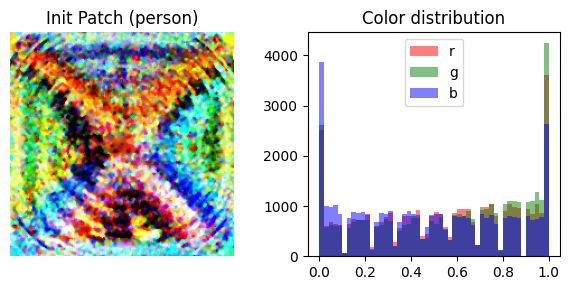

In [54]:
# ================================================================
# INIT PATCH 
# Priority: warm-start from file → texture from dataset → random
# ================================================================

def init_patch_from_dataset_crops(pairs, dataset_cls, patch_h, patch_w,
                                   n_samples=100, seed=42,
                                   center_crop_ratio=0.65):  # ← New parameter added
    """
    Extract random crops from the bounding box regions of the dataset and compute their average.
    Improvement: Only extract the CENTER region of the bounding box to reduce background interference.
    - center_crop_ratio: Ratio of the crop size relative to the original box (0.5-0.8).
    Result: A patch with representative colors, avoiding excessive randomness.
    Note: This serves only as the INITIALIZATION POINT, not as a texture loss.
    """
    rng = random.Random(seed)
    sampled = rng.sample(pairs, min(n_samples, len(pairs)))
    crops = []
    for img_path, _, bboxes in sampled:
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]
        for cls, cx, cy, bw, bh in bboxes:
            if int(cls) != dataset_cls:
                continue
            
            # ── COMPUTE ORIGINAL BOUNDING BOX COORDINATES ──────────────────
            x1_full = int((cx - bw/2) * W)
            y1_full = int((cy - bh/2) * H)
            x2_full = int((cx + bw/2) * W)
            y2_full = int((cy + bh/2) * H)
            
            # Clip to prevent coordinates from exceeding image boundaries
            x1_full = max(0, x1_full)
            y1_full = max(0, y1_full)
            x2_full = min(W, x2_full)
            y2_full = min(H, y2_full)
            
            # ── COMPUTE CENTER CROP REGION (EXTRACT CENTER ONLY) ───────────
            box_w = x2_full - x1_full
            box_h = y2_full - y1_full
            
            if box_w < 16 or box_h < 16:  # ← Threshold increased from 8 → 16
                continue
            
            # Dimensions of the center crop region
            crop_w = int(box_w * center_crop_ratio)
            crop_h = int(box_h * center_crop_ratio)
            
            # Compute center crop coordinates (preserving the original center cx, cy)
            x1 = int(x1_full + (box_w - crop_w) / 2)
            y1 = int(y1_full + (box_h - crop_h) / 2)
            x2 = x1 + crop_w
            y2 = y1 + crop_h
            
            # Re-clip after computing the center crop
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(W, x2)
            y2 = min(H, y2)
            
            if x2 - x1 < 8 or y2 - y1 < 8:
                continue
            
            # ── CROP AND RESIZE (RETAIN ORIGINAL LOGIC) ────────────────────
            crop = cv2.resize(img[y1:y2, x1:x2], (patch_w, patch_h))
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            crops.append(torch.from_numpy(crop_rgb).float().permute(2,0,1) / 255.0)
            if len(crops) >= n_samples:
                break
        if len(crops) >= n_samples:
            break
    if not crops:
        print('  ⚠️  No crops extracted, falling back to random initialization')
        return torch.rand(3, patch_h, patch_w) * 0.4 + 0.3
    avg = torch.stack(crops).mean(dim=0).clamp(0, 1)
    print(f'  ✅ Initialized from {len(crops)} crops (dataset color average, center_ratio={center_crop_ratio})')
    return avg


# ── PATCH INITIALIZATION (RETAINED) ──────────────────────────────────────
if INIT_PATCH_PATH and Path(INIT_PATCH_PATH).exists():
    ext = Path(INIT_PATCH_PATH).suffix.lower()
    if ext == '.pt':
        raw = torch.load(INIT_PATCH_PATH, map_location='cpu')
    else:
        bgr = cv2.imread(str(INIT_PATCH_PATH))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        raw = torch.from_numpy(rgb).float().permute(2,0,1) / 255.0
    if raw.shape != (3, PATCH_H, PATCH_W):
        raw = F.interpolate(raw.unsqueeze(0), (PATCH_H, PATCH_W),
                            mode='bilinear', align_corners=False).squeeze(0)
    init_patch = raw.clamp(0, 1)
    print(f'✅ Warm-start from: {INIT_PATCH_PATH}')
else:
    # Initialize from the average color of objects in the dataset
    init_patch = init_patch_from_dataset_crops(
        train_pairs, DATASET_CLS, PATCH_H, PATCH_W, 
        n_samples=1,              # ← Increased from 10 → 50 for better stability
        center_crop_ratio=0.65     # ← New parameter added
    )

# ── VISUALIZATION (100% RETAINED) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(init_patch.permute(1,2,0).numpy())
axes[0].set_title(f'Init Patch ({CLASS_MODE})')
axes[0].axis('off')
# Color histogram
for i, c in enumerate(['r','g','b']):
    axes[1].hist(init_patch[i].numpy().flatten(), bins=50,
                 color=c, alpha=0.5, label=c)
axes[1].set_title('Color distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

## 🔧 Components (Augment, Hooks, Loss, Optimizer)

In [55]:
# ================================================================
# 1. AUGMENTATION — Bbox-aware, constrained as in the T-SEA paper 
# ================================================================
def augment_image_and_bboxes(img_bgr, bboxes):
    """
    Perform joint augmentation of the image and its bounding boxes.
    Only mild spatial augmentation and color jitter are applied.
    bboxes: list of (cls, cx, cy, bw, bh) normalized in [0, 1]
    """
    H, W = img_bgr.shape[:2]
    img  = img_bgr.copy()
    bbs  = [list(b) for b in bboxes]

    # 1) Horizontal flip
    if random.random() < 0.5:
        img = cv2.flip(img, 1)
        bbs = [[cls, 1.0 - cx, cy, bw, bh] for cls, cx, cy, bw, bh in bbs]

    # 2) Color jitter — does not affect bounding box coordinates
    if random.random() < 0.5:
        pil = PIL_Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        pil = T_tv.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.15, hue=0.04
        )(pil)
        img = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)

    # 3) Mild crop (90-100%) — precise bounding box transformation
    if random.random() < 0.5:
        scale = random.uniform(0.90, 1.0)
        cw = int(W * scale)
        ch = int(H * scale)
        j  = random.randint(0, max(0, W - cw))
        i  = random.randint(0, max(0, H - ch))
        img_crop = img[i:i+ch, j:j+cw]
        img_crop = cv2.resize(img_crop, (W, H), interpolation=cv2.INTER_LINEAR)
        new_bbs  = []
        for cls, cx, cy, bw, bh in bbs:
            cx_new = (cx * W - j) / cw
            cy_new = (cy * H - i) / ch
            bw_new = bw * W / cw
            bh_new = bh * H / ch
            if 0.05 < cx_new < 0.95 and 0.05 < cy_new < 0.95:
                new_bbs.append([cls,
                    float(np.clip(cx_new, 0.01, 0.99)),
                    float(np.clip(cy_new, 0.01, 0.99)),
                    float(min(bw_new, 1.0)),
                    float(min(bh_new, 1.0))])
        if new_bbs:
            img = img_crop
            bbs = new_bbs

    return img, bbs


# ================================================================
# 2. LETTERBOX RESIZE — Identical to YOLO inference, preserving aspect ratio
# ================================================================
def letterbox_resize(img_bgr, target_size=640, fill_val=114):
    """
    Resize the image to target_size × target_size with letterbox padding.
    Returns (img_letterboxed, ratio, (dw, dh)) for bounding box transformation.
    """
    H, W  = img_bgr.shape[:2]
    ratio = min(target_size / H, target_size / W)
    nW    = int(round(W * ratio))
    nH    = int(round(H * ratio))
    img_r = cv2.resize(img_bgr, (nW, nH), interpolation=cv2.INTER_LINEAR)

    dw = (target_size - nW) / 2
    dh = (target_size - nH) / 2
    top, bot = int(round(dh - 0.1)), int(round(dh + 0.1))
    lft, rgt = int(round(dw - 0.1)), int(round(dw + 0.1))
    img_lb   = cv2.copyMakeBorder(
        img_r, top, bot, lft, rgt,
        cv2.BORDER_CONSTANT, value=(fill_val, fill_val, fill_val)
    )
    return img_lb, ratio, (lft, top)


def transform_bboxes_letterbox(bboxes, orig_hw, ratio, pad_xy, target_size=640):
    """
    Transform normalized bounding boxes from the original image to the letterbox image.
    orig_hw: (H, W) of the original image
    pad_xy: (pad_left, pad_top) in pixels
    """
    H0, W0       = orig_hw
    pad_l, pad_t = pad_xy
    new_bbs      = []
    for cls, cx, cy, bw, bh in bboxes:
        # Pixel coordinates in the letterbox image
        cx_px = cx * W0 * ratio + pad_l
        cy_px = cy * H0 * ratio + pad_t
        bw_px = bw * W0 * ratio
        bh_px = bh * H0 * ratio
        # Re-normalize according to target_size
        new_bbs.append((cls,
            float(np.clip(cx_px / target_size, 0.01, 0.99)),
            float(np.clip(cy_px / target_size, 0.01, 0.99)),
            float(min(bw_px  / target_size, 1.0)),
            float(min(bh_px  / target_size, 1.0))))
    return new_bbs


print('✅ Augmentation OK')

✅ Augmentation OK


In [56]:
# ================================================================
# CV3 HOOKS 
# ================================================================
_cv3_feats   = []
_cv3_hooks   = []
_hooks_ready = False

def _register_cv3_hooks():
    global _cv3_feats, _cv3_hooks, _hooks_ready
    for h in _cv3_hooks:
        h.remove()
    _cv3_hooks = []; _cv3_feats = []
    detect = yolo_wrapper.model.model[-1]
    for i in range(3):
        h = detect.cv3[i][-1].register_forward_hook(
            lambda m, inp, out: _cv3_feats.append(out)
        )
        _cv3_hooks.append(h)
    _hooks_ready = True
    print(f'  cv3 hooks: {len(_cv3_hooks)} scales')

_register_cv3_hooks()


def _bbox_anchor_mask_from_feat(bboxes, coco_classes, feat, img_size=640):
    """
    Tạo anchor mask cho list coco_classes (hỗ trợ nhiều class = vehicle)
    bboxes: dùng dataset label (0=car, 1=person)
    coco_classes: list COCO id tương ứng với dataset label đó
    Mask = union của tất cả bbox thuộc bất kỳ class nào trong coco_classes.
    """
    _, _, gH, gW = feat.shape
    stride_h = img_size / gH
    stride_w = img_size / gW
    mask = torch.zeros(gH * gW, dtype=torch.bool)

    # dataset label của SOURCE class
    dataset_src_cls = DATASET_CLS

    for cls, cx, cy, bw, bh in bboxes:
        if int(cls) != dataset_src_cls:
            continue
        # Pixel coords trong ảnh img_size×img_size
        x1 = (cx - bw / 2) * img_size
        y1 = (cy - bh / 2) * img_size
        x2 = (cx + bw / 2) * img_size
        y2 = (cy + bh / 2) * img_size
        # Grid cell range
        gi1 = max(0, int(x1 / stride_w))
        gi2 = min(gW, int(x2 / stride_w) + 1)
        gj1 = max(0, int(y1 / stride_h))
        gj2 = min(gH, int(y2 / stride_h) + 1)
        for gj in range(gj1, gj2):
            for gi in range(gi1, gi2):
                mask[gj * gW + gi] = True
    return mask


print('✅ Hooks OK')

  cv3 hooks: 3 scales
✅ Hooks OK


In [57]:
# ================================================================
# TARGETED CONFIDENCE LOSS
# Simultaneously computes:
#   conf_source: confidence of the correct class (to be minimized)
#   conf_target: confidence of the wrong class (to be maximized)
#
# Total loss = λ_src * conf_source - λ_tgt * conf_target + λ_tv * tv
# Minimizing the loss → decreases conf_source and increases conf_target
# ================================================================

def extract_conf_targeted(model, img_tensor, bboxes,
                           source_classes, target_classes,
                           topk=60):
    """
    source_classes: list of COCO class IDs to suppress (e.g., [0] or [2, 5, 7])
    target_classes: list of COCO class IDs to promote (e.g., [10, 11] or [9, 13])
    bboxes: bounding boxes using dataset labels (0=car, 1=person)

    Returns:
        conf_source: mean of the top-K sigmoid logits for the source class (within the bounding boxes)
        conf_target: mean of the top-K sigmoid logits for the target class (across the entire image)
        has_target:  True if there are anchors within the bounding boxes
    """
    global _cv3_feats
    _cv3_feats = []
    _ = model(img_tensor)

    if not _cv3_feats:
        return None, None, False

    # ── Source: focused (only anchors within the bounding boxes) ─────────────────
    src_logits = []
    has_any    = False

    for feat in _cv3_feats:
        # feat shape: (B, nc, gH, gW), nc=80 for the pretrained model
        anchor_mask = _bbox_anchor_mask_from_feat(
            bboxes, source_classes, feat, IMG_SIZE
        ).to(feat.device)

        if not anchor_mask.any():
            continue
        has_any = True

        for sc in source_classes:
            if sc >= feat.shape[1]:
                continue
            logit_flat = feat[0, sc, :, :].reshape(-1)
            src_logits.append(logit_flat[anchor_mask])

    # Fallback if no bounding box matches are found
    if not src_logits:
        all_logits = []
        for feat in _cv3_feats:
            for sc in source_classes:
                if sc < feat.shape[1]:
                    all_logits.append(feat[0, sc, :, :].reshape(-1))
        if not all_logits:
            return None, None, False
        cat = torch.cat(all_logits)
        k   = min(topk, cat.shape[0])
        conf_src = torch.sigmoid(cat).topk(k).values.mean()
        return conf_src, torch.tensor(0.0, device=feat.device), False

    cat_src  = torch.cat(src_logits)
    k_s      = min(topk, cat_src.shape[0])
    conf_src = torch.sigmoid(cat_src).topk(k_s).values.mean()

    # ── Target: entire image (not restricted to bounding boxes) ───────────────────
    # Rationale: The target classes (e.g., hydrant/bench) lack ground-truth bounding boxes,
    # so the entire feature map is utilized to maximize their confidence.
    tgt_logits = []
    for feat in _cv3_feats:
        for tc in target_classes:
            if tc < feat.shape[1]:
                tgt_logits.append(feat[0, tc, :, :].reshape(-1))

    conf_tgt = torch.tensor(0.0, device=img_tensor.device)
    if tgt_logits:
        cat_tgt  = torch.cat(tgt_logits)
        k_t      = min(topk, cat_tgt.shape[0])
        conf_tgt = torch.sigmoid(cat_tgt).topk(k_t).values.mean()

    return conf_src, conf_tgt, has_any


print('✅ Targeted loss function OK')
print(f'   Source: {SOURCE_CLASSES} ({SOURCE_NAME})')
print(f'   Target: {TARGET_CLASSES} ({TARGET_NAME})')

✅ Targeted loss function OK
   Source: [0] (person)
   Target: [10, 11] (fire_hydrant+parking_meter)


In [58]:
# ================================================================
# APPLY PATCH + TV LOSS + SHAKEDROP + CUTOUT + MIM + SCHEDULER
# ================================================================
def _rotate_patch_differentiable(patch, angle_deg):
    angle_rad = torch.tensor(angle_deg * 3.14159265 / 180.0)
    cos_a = torch.cos(angle_rad)
    sin_a = torch.sin(angle_rad)
    theta = torch.zeros(1, 2, 3, device=patch.device)
    theta[0, 0, 0] =  cos_a
    theta[0, 0, 1] =  sin_a
    theta[0, 1, 0] = -sin_a
    theta[0, 1, 1] =  cos_a
    grid = F.affine_grid(
        theta,
        (1, 3, patch.shape[1], patch.shape[2]),
        align_corners=True          
    )
    rotated = F.grid_sample(
        patch.unsqueeze(0), grid,
        mode='bilinear',
        padding_mode='border',      
        align_corners=True          
    )
    return rotated.squeeze(0)

def apply_patch_to_image(img, bboxes, patch,
                          scale=PATCH_SCALE, anchor_y=PATCH_ANCHOR_Y,
                          target_dataset_cls=None,
                          do_cutout=False, alpha=0.9,
                          collect_regions=True):
    if alpha is None:
        alpha = PATCH_ALPHA
    out     = img.clone()
    _, H, W = out.shape
    p_aspect= patch.shape[1] / patch.shape[2]
    p_use   = patch_cutout(patch) if do_cutout else patch
    regions = []

    for (cls, cx, cy, bw, bh) in bboxes:
        if target_dataset_cls is not None and int(cls) != int(target_dataset_cls):
            continue
        pw = max(MIN_PATCH_PX, int(bw*W*scale))
        pw = min(pw, int(bw*W*0.90))
        ph = max(MIN_PATCH_PX, int(pw*p_aspect))
        ph = min(ph, int(bh*H*0.90))
        pw = max(MIN_PATCH_PX, int(ph/p_aspect))

        angle     = random.uniform(-10, 10)
        p_rotated = _rotate_patch_differentiable(p_use, angle)      # rotate full-size
        p_resized = F.interpolate(p_rotated.unsqueeze(0), size=(ph,pw),
                                   mode='bilinear', align_corners=False).squeeze(0)

        rx  = random.uniform(-0.05, 0.05)
        acx = cx + bw*rx
        half_pw_norm = (pw/2)/W
        acx = max((cx-bw/2)+half_pw_norm, min((cx+bw/2)-half_pw_norm, acx))
        acy = (cy - bh/2) + bh*anchor_y

        x1 = max(0, min(W-pw, int(acx*W - pw//2)))
        y1 = max(0, min(H-ph, int(acy*H - ph//2)))
        x2, y2 = x1+pw, y1+ph

        if collect_regions:
            region = img[:, y1:y2, x1:x2].detach().clone()
            if region.shape[1]==ph and region.shape[2]==pw:
                regions.append((p_resized, region))

        mask               = torch.zeros_like(out)
        pr_full            = torch.zeros_like(out)
        mask[:,   y1:y2, x1:x2] = 1.0
        pr_full[:, y1:y2, x1:x2] = p_resized
        out = (1.0-mask)*out + mask*(alpha*pr_full + (1.0-alpha)*img)

    if collect_regions:
        return out, regions
    return out


def tv_loss(patch):
    diff_h = (patch[:,1:,:] - patch[:,:-1,:]).abs().mean()
    diff_w = (patch[:,:,1:] - patch[:,:,:-1]).abs().mean()
    return diff_h + diff_w

# ================================================================
# [C] TEXTURE LOSS
# ================================================================
def compute_texture_loss(regions):
    """
    regions: list of (patch_rendered, region_original)
    Penalizes patch for differing from the real image pixels at paste location.
    Patch converges to average color of all paste regions across training images.
    """
    if not regions or TEXTURE_LAMBDA == 0:
        return torch.tensor(0.0)
    total = torch.tensor(0.0)
    for p_rendered, r_original in regions:
        if p_rendered.shape == r_original.shape:
            total = total + F.mse_loss(p_rendered, r_original.to(p_rendered.device))
    return total / len(regions)
    
def patch_cutout(patch, prob=CUTOUT_PROB, ratio=CUTOUT_RATIO, fill=0.5):
    if random.random() > prob:
        return patch
    _, H, W = patch.shape
    ch = int(H*ratio); cw = int(W*ratio)
    cy = random.randint(ch//2, max(ch//2+1, H-ch//2))
    cx = random.randint(cw//2, max(cw//2+1, W-cw//2))
    y1,y2 = max(0,cy-ch//2), min(H,cy+ch//2)
    x1,x2 = max(0,cx-cw//2), min(W,cx+cw//2)
    mask   = torch.ones_like(patch)
    mask[:, y1:y2, x1:x2] = 0.0
    return patch*mask + fill*(1.0-mask)

class ShakeDropHook:
    def __init__(self, model, prob=0.5, e=0.5):
        self.prob=prob; self.e=e; self.active=True; self.handles=[]
        count=0
        for _, mod in model.named_modules():
            if any(k in type(mod).__name__ for k in ['C3k2','C3k','C2f','Bottleneck']):
                self.handles.append(mod.register_forward_hook(self._hook))
                count+=1
        print(f'  ShakeDrop: {count} hooks')
    def _hook(self, module, inputs, output):
        if not self.active: return None
        if not torch.bernoulli(torch.tensor(self.prob)).item(): return None
        alpha = random.uniform(1.0-self.e, 1.0+self.e)
        if isinstance(inputs,(tuple,list)) and len(inputs)>0:
            skip = inputs[0]
            if skip.shape==output.shape:
                return skip + alpha*(output-skip)
        return alpha*output
    def enable(self):  self.active=True
    def disable(self): self.active=False
    def remove(self):
        for h in self.handles: h.remove()
        self.handles=[]


class MIMOptimizer:
    def __init__(self, patch_shape, lr=0.05, mu=0.9):
        self.lr=lr; self.mu=mu
        self.momentum = torch.zeros(patch_shape)
    def step(self, patch_data, grad):
        g_norm = grad / (grad.abs().mean()+1e-8)
        self.momentum = self.momentum.to(grad.device)
        self.momentum  = self.mu*self.momentum + g_norm
        with torch.no_grad():
            delta = self.lr * self.momentum.sign()
            at_min = (patch_data<=0.0) & (delta > 0)
            at_max = (patch_data>=1.0) & (delta < 0)
            delta[at_min]=0.0; delta[at_max]=0.0
            patch_data.sub_(delta)
            patch_data.clamp_(0.0, 1.0)
    def reset_momentum(self): self.momentum.zero_()
 
class PatienceScheduler:
    def __init__(self, optimizer, decay=0.5, patience=5,
                 min_delta=1e-3, lr_min=1e-4):
        self.opt=optimizer; self.decay=decay; self.patience=patience
        self.min_delta=min_delta; self.lr_min=lr_min
        self.best=float('inf'); self.counter=0
    def step(self, loss):
        if loss < self.best - self.min_delta:
            self.best=loss; self.counter=0; return False
        self.counter+=1
        if self.counter >= self.patience:
            new_lr = max(self.opt.lr*self.decay, self.lr_min)
            if new_lr < self.opt.lr:
                self.opt.lr=new_lr; self.opt.reset_momentum()
                self.counter=0; return True
        return False

print('✅ All components OK')

✅ Tất cả components OK


## 🔍 Gradient Sanity Check

In [61]:
# ================================================================
# GRADIENT SANITY CHECK
# Verification:
#   1. conf_source decreases during optimization → patch is suppressing the correct class
#   2. conf_target increases during optimization → patch is promoting the wrong class
#   3. Verify if requires_grad is properly enabled for the loss
# ================================================================
print('🔍 Gradient Sanity Check...')
model.eval()
dev = DEVICE

img_path, _, bboxes_raw = train_pairs[0]
bgr = cv2.imread(img_path)
H0, W0 = bgr.shape[:2]
img_lb, ratio, pad_xy = letterbox_resize(bgr, IMG_SIZE)
bboxes_lb = transform_bboxes_letterbox(bboxes_raw, (H0,W0), ratio, pad_xy, IMG_SIZE)

rgb   = cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB)
img_t = torch.from_numpy(rgb).float().permute(2,0,1).to(dev) / 255.0

test_patch = init_patch.clone().to(dev).requires_grad_(True)

# ── Apply patch WITH collect_regions=True ─────────────────────────────────
adv, regions = apply_patch_to_image(
    img_t, bboxes_lb, test_patch,
    PATCH_SCALE, PATCH_ANCHOR_Y,
    DATASET_CLS,            
    do_cutout=False,
    collect_regions=True
)

conf_src, conf_tgt, has_target = extract_conf_targeted(
    model, adv.unsqueeze(0), 
    bboxes_lb,
    SOURCE_CLASSES, TARGET_CLASSES, topk=60
)
print(f'  has_target   : {has_target}')
print(f'  conf_source  : {conf_src.item():.4f}  (should decrease toward 0)')
print(f'  conf_target  : {conf_tgt.item():.4f}  (should increase toward 1)')

# ── Compute Texture Loss from regions ─────────────────────────────────────
texture_loss = compute_texture_loss(regions)
print(f'texture_loss                   : {texture_loss.item():.6f}')

# ── Total Loss ────────────────────────────────────────────────────────────
tv = tv_loss(test_patch)
total_loss = (LAMBDA_SOURCE * conf_src
              - LAMBDA_TARGET * conf_tgt
              + TV_LAMBDA * tv
              + TEXTURE_LAMBDA * texture_loss)
print(f'tv_loss (weighted)             : {(TV_LAMBDA * tv).item():.6f}')
print(f'texture_loss (weighted)        : {(TEXTURE_LAMBDA * texture_loss).item():.6f}')
print(f'→ total_loss                   : {total_loss.item():.4f}')
print(f'  requires_grad                : {total_loss.requires_grad}')

# ── Backward pass ─────────────────────────────────────────────────────────
total_loss.backward()

# ── Check gradient flow ───────────────────────────────────────────────────
if test_patch.grad is None or test_patch.grad.abs().sum() == 0:
    print('❌ GRADIENT = 0!')
    print('   → Verify: cv3 hooks registered? collect_regions=True?')
else:
    g_norm = test_patch.grad.abs().mean().item()
    g_max  = test_patch.grad.abs().max().item()
    print(f'✅ Gradient OK: mean={g_norm:.6f}  max={g_max:.4f}')

    # ── Test a single update step ─────────────────────────────────────────
    with torch.no_grad():
        p_updated = (test_patch - 0.05 * test_patch.grad.sign()).clamp(0, 1)

    adv2, _ = apply_patch_to_image(
        img_t, bboxes_lb, p_updated,
        PATCH_SCALE, PATCH_ANCHOR_Y,
        DATASET_CLS,
        do_cutout=False,
        collect_regions=True
    )

    # Use extract_conf_targeted (consistent with the training loop)
    conf_src2, conf_tgt2, _ = extract_conf_targeted(
        model, adv2.unsqueeze(0),
        bboxes_lb, SOURCE_CLASSES, TARGET_CLASSES, topk=60
    )

    print(f'conf_source after 1 update step: {conf_src2.item():.4f}  '
          f'(before: {conf_src.item():.4f})')
    print(f'conf_target after 1 update step: {conf_tgt2.item():.4f}  '
          f'(before: {conf_tgt.item():.4f})')

    src_ok = conf_src2.item() < conf_src.item()
    tgt_ok = conf_tgt2.item() > conf_tgt.item()

    if src_ok:
        print('✅ conf_source DECREASED — suppressing in the correct direction')
    else:
        print('⚠️  conf_source did not decrease')

    if tgt_ok:
        print('✅ conf_target INCREASED — promoting in the correct direction')
    else:
        print('⚠️  conf_target did not increase (normal if λ_tgt is small)')

    if src_ok:
        print('\n✅ Pipeline OK — ready to start training')
    else:
        print('\n⚠️  Re-examine TEXTURE_LAMBDA — if too large, it may be counter-productive')
        print(f'   Current TEXTURE_LAMBDA = {TEXTURE_LAMBDA}')
        print(f'   Try setting TEXTURE_LAMBDA = 0 to isolate the issue')

🔍 Gradient Sanity Check...
  has_target   : True
  conf_source  : 0.2237  (muốn giảm về 0)
  conf_target  : 0.0017  (muốn tăng về 1)
texture_loss                   : 0.314160
tv_loss (weighted)             : 0.000915
texture_loss (weighted)        : 0.000314
→ total_loss                   : 0.2688
  requires_grad                : True
✅ Gradient OK: mean=0.000051  max=0.0091
conf_source sau 1 bước update  : 0.1891  (trước: 0.2237)
conf_target sau 1 bước update  : 0.0017  (trước: 0.0017)
✅ conf_source GIẢM — suppress đúng hướng
⚠️  conf_target không tăng (bình thường nếu λ_tgt nhỏ)

✅ Pipeline OK — có thể bắt đầu training


## 👁️ Visual Debug 

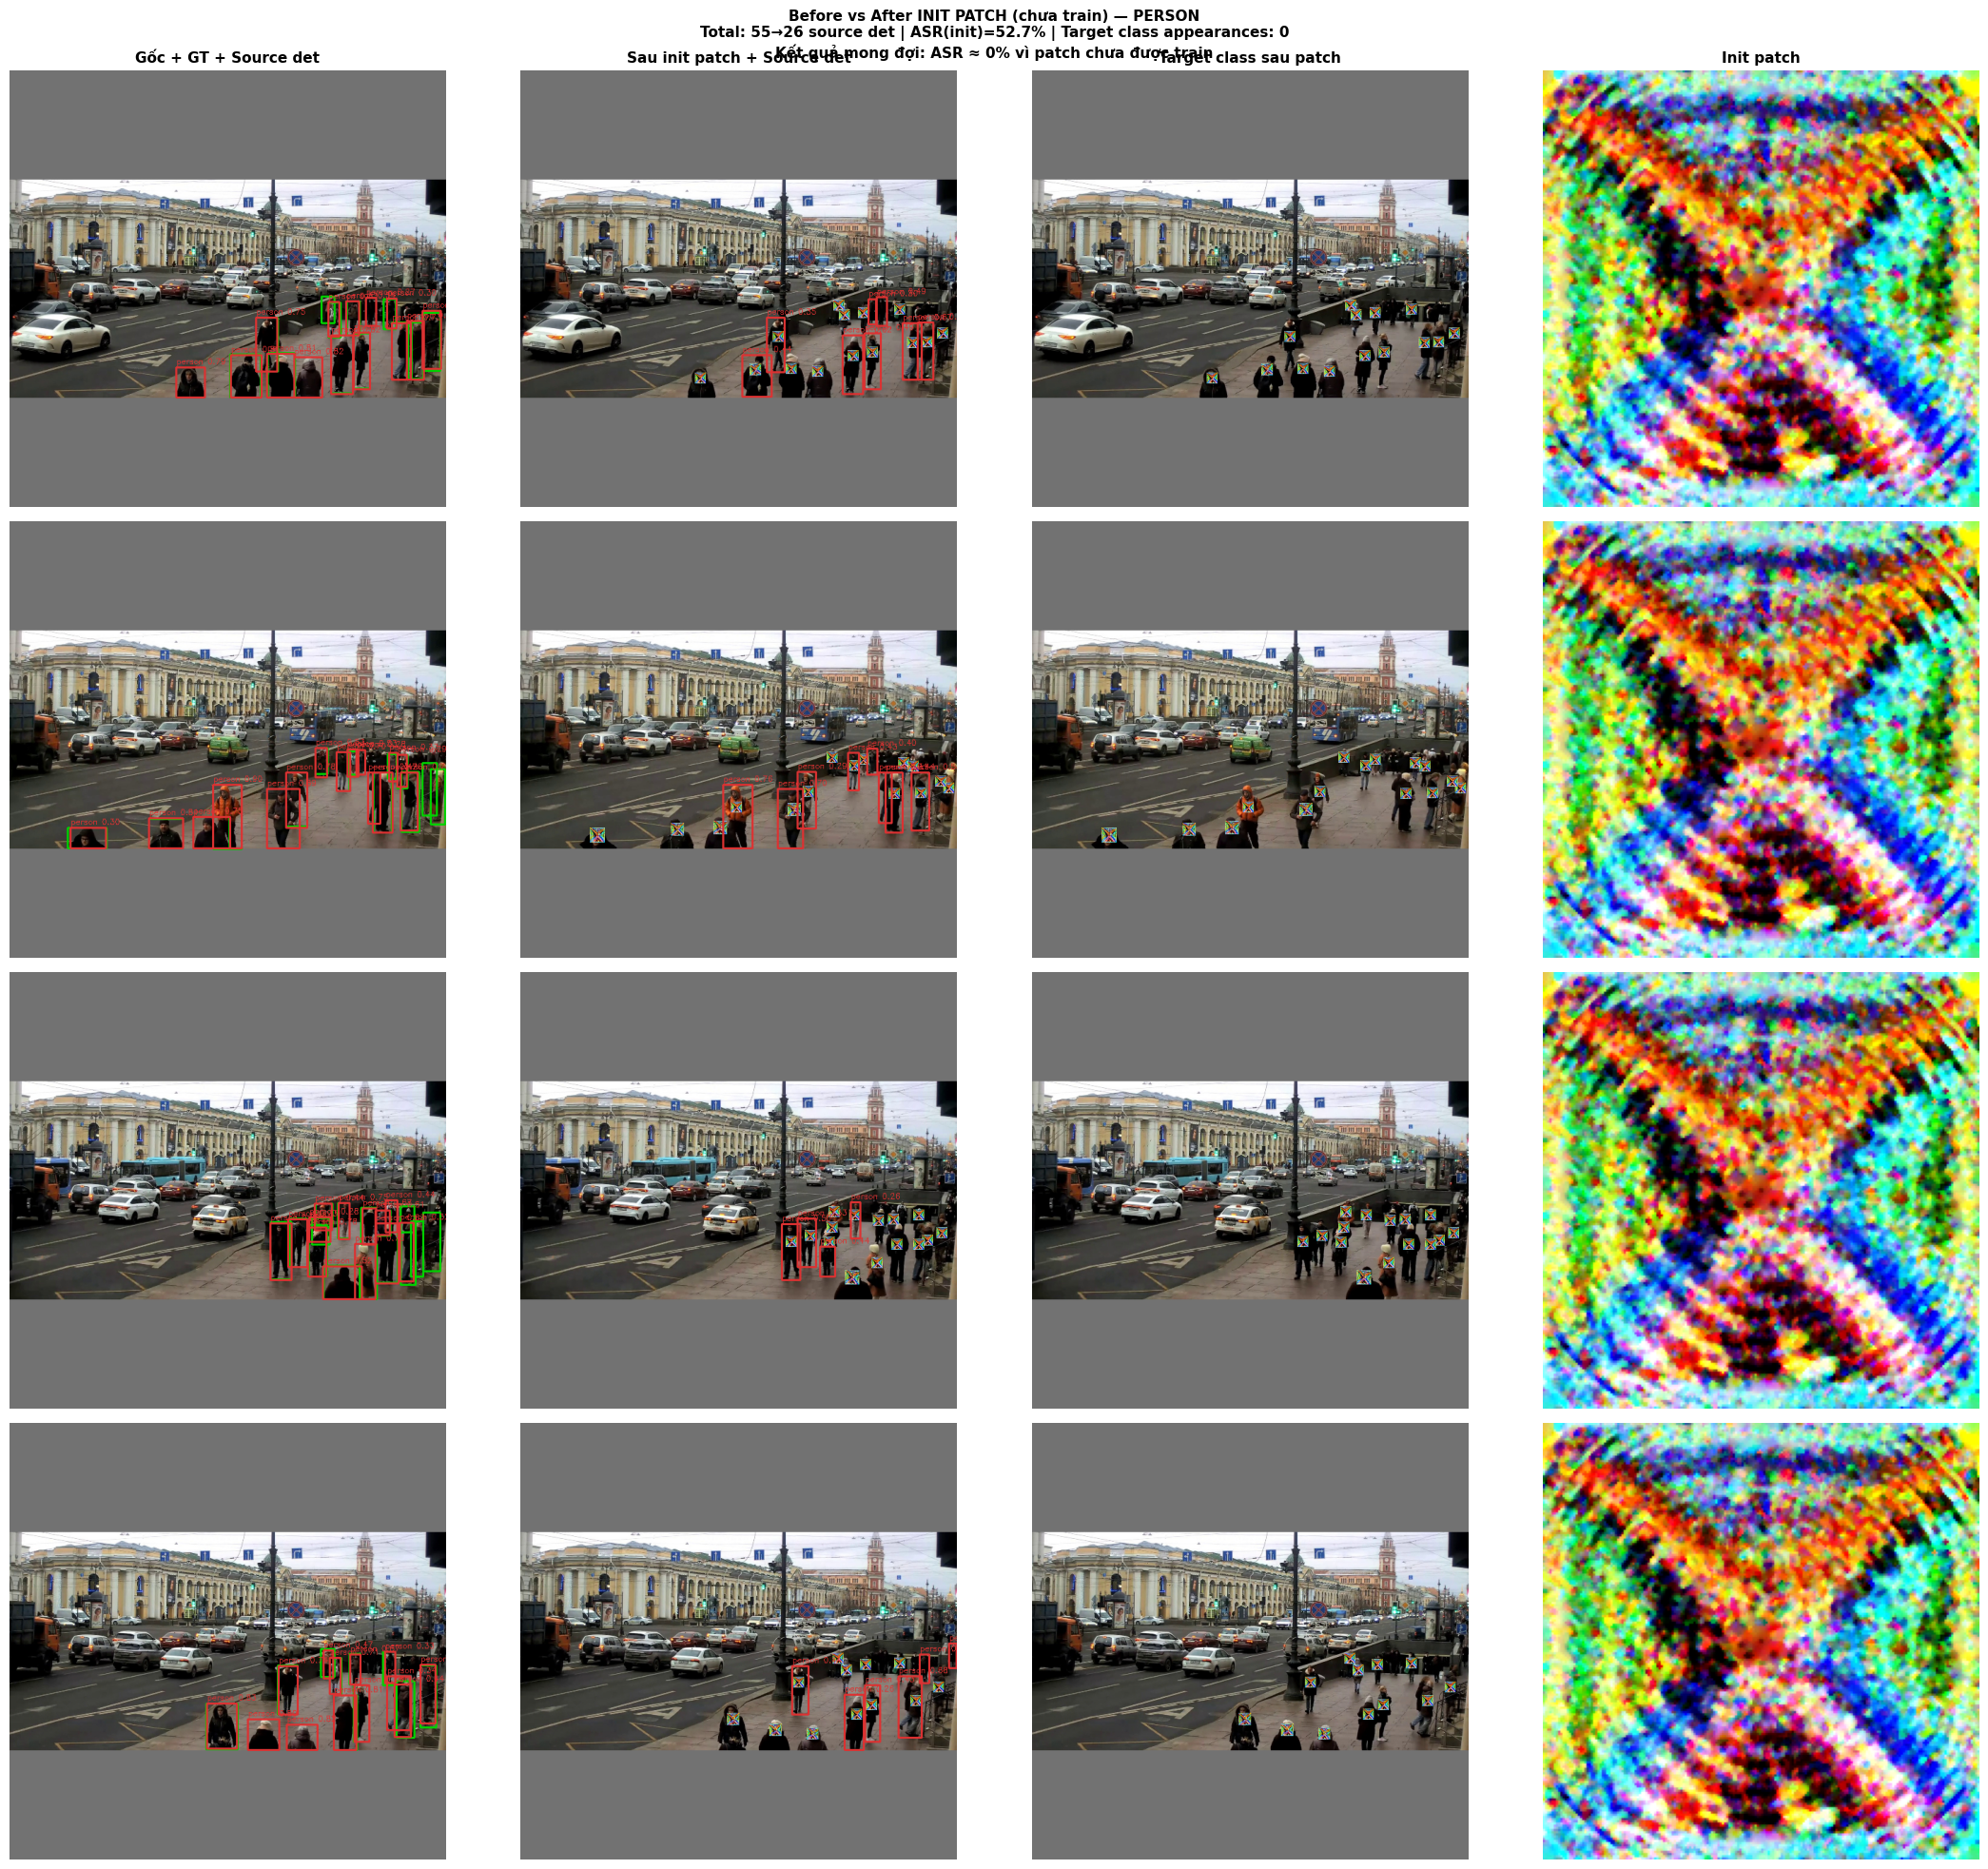

✅ Saved before_after_init.png
   ASR với init patch (random): 52.7%
   ⚠️  ASR khác 0 đáng kể ngay với init patch → có thể detection không khớp với GT bbox


In [62]:
# ================================================================
# VISUALIZATION: BEFORE vs AFTER PATCH
# ================================================================
model.eval()
N_SHOW = 4

fig, axes = plt.subplots(N_SHOW, 4, figsize=(22, 5*N_SHOW))
col_titles = [
    'Original + GT + Source Detection',
    'After Init Patch + Source Detection',
    'Target Class After Patch',
    'Init Patch'
]
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=11, fontweight='bold')

total_before = 0
total_after  = 0
total_tgt    = 0

for idx in range(N_SHOW):
    img_path, _, bboxes_raw = val_pairs[idx]
    bgr  = cv2.imread(img_path)
    H0, W0 = bgr.shape[:2]
    img_lb, ratio, pad_xy = letterbox_resize(bgr, IMG_SIZE)
    bboxes_lb = transform_bboxes_letterbox(
        bboxes_raw, (H0,W0), ratio, pad_xy, IMG_SIZE)
    rgb   = cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB)
    img_t = torch.from_numpy(rgb).float().permute(2,0,1).to(DEVICE)/255.0

    with torch.no_grad():
        # Original detection
        r_orig = yolo_wrapper.predict(
            img_t.unsqueeze(0), conf=CONF_THRESHOLD,
            classes=SOURCE_CLASSES, verbose=False)

        # Apply init patch
        adv = apply_patch_to_image(
            img_t, bboxes_lb, init_patch.to(DEVICE),
            PATCH_SCALE, PATCH_ANCHOR_Y, DATASET_CLS,
            do_cutout=False, alpha=PATCH_ALPHA,
            collect_regions=False
        )

        # Detection after patch (source class)
        r_after = yolo_wrapper.predict(
            adv.unsqueeze(0), conf=CONF_THRESHOLD,
            classes=SOURCE_CLASSES, verbose=False)

        # Detection after patch (target class)
        r_tgt = yolo_wrapper.predict(
            adv.unsqueeze(0), conf=CONF_THRESHOLD,
            classes=TARGET_CLASSES, verbose=False)

    n_before = len(r_orig[0].boxes)
    n_after  = len(r_after[0].boxes)
    n_tgt    = len(r_tgt[0].boxes)
    total_before += n_before
    total_after  += n_after
    total_tgt    += n_tgt

    orig_np = rgb.copy()
    adv_np  = (adv.cpu().clamp(0,1).permute(1,2,0).numpy()*255).astype('uint8')
    tgt_np  = adv_np.copy()

    # Column 1: Original — Ground-truth (green) + Source detection (red)
    for cls, cx, cy, bw, bh in bboxes_lb:
        if int(cls) != DATASET_CLS: continue
        x1=int((cx-bw/2)*IMG_SIZE); y1=int((cy-bh/2)*IMG_SIZE)
        x2=int((cx+bw/2)*IMG_SIZE); y2=int((cy+bh/2)*IMG_SIZE)
        cv2.rectangle(orig_np, (x1,y1),(x2,y2), (0,210,0), 2)
    for box in r_orig[0].boxes:
        x1,y1,x2,y2 = box.xyxy[0].int().tolist()
        cv2.rectangle(orig_np,(x1,y1),(x2,y2),(220,50,50),2)
        cv2.putText(orig_np, f'{coco_names[int(box.cls)]} {float(box.conf):.2f}',
                    (x1,max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (220,50,50), 1)

    # Column 2: After patch — Source detection
    adv_src = adv_np.copy()
    for box in r_after[0].boxes:
        x1,y1,x2,y2 = box.xyxy[0].int().tolist()
        cv2.rectangle(adv_src,(x1,y1),(x2,y2),(220,50,50),2)
        cv2.putText(adv_src, f'{coco_names[int(box.cls)]} {float(box.conf):.2f}',
                    (x1,max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (220,50,50), 1)

    # Column 3: After patch — Target class (misclassification)
    for box in r_tgt[0].boxes:
        x1,y1,x2,y2 = box.xyxy[0].int().tolist()
        cv2.rectangle(tgt_np,(x1,y1),(x2,y2),(50,180,255),2)
        cv2.putText(tgt_np, f'→{coco_names[int(box.cls)]} {float(box.conf):.2f}',
                    (x1,max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (50,180,255), 1)

    axes[idx,0].imshow(orig_np)
    axes[idx,0].set_xlabel(f'Source det: {n_before}', fontsize=10)
    axes[idx,1].imshow(adv_src)
    axes[idx,1].set_xlabel(f'Source det: {n_after} (Δ={n_after-n_before:+d})', fontsize=10)
    axes[idx,2].imshow(tgt_np)
    axes[idx,2].set_xlabel(f'Target class: {n_tgt} ({TARGET_NAME})', fontsize=10)
    axes[idx,3].imshow(init_patch.cpu().clamp(0,1).permute(1,2,0).numpy())
    axes[idx,3].set_xlabel('Init patch', fontsize=10)
    for ax in axes[idx]: ax.axis('off')

asr_init = (total_before-total_after)/max(total_before,1)*100
plt.suptitle(
    f'Before vs After INIT PATCH (Untrained) — {CLASS_MODE.upper()}\n'
    f'Total: {total_before}→{total_after} source detections | '
    f'ASR(init)={asr_init:.1f}% | '
    f'Target class appearances: {total_tgt}\n'
    f'Expected result: ASR ≈ 0% since the patch has not been trained yet',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(Path(WORK_DIR)/'results'/f'{EXP_NAME}_before_after_init.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Saved before_after_init.png')
print(f'   ASR with init patch (random): {asr_init:.1f}%')
if abs(asr_init) > 20:
    print(f'   ⚠️  ASR significantly differs from 0 even with init patch → '
          'detections may not align with ground-truth bounding boxes')
else:
    print(f'   ✅ ASR close to 0 → pipeline OK, patch is untrained and thus ineffective')

## 🚀 Training Loop — Targeted Attack

In [47]:
def tensor_to_bgr(img_t):
    """Tensor [3,H,W] → uint8 BGR numpy."""
    return cv2.cvtColor(
        (img_t.cpu().clamp(0,1).permute(1,2,0).numpy()*255).astype(np.uint8),
        cv2.COLOR_RGB2BGR)

In [63]:
dev = DEVICE
model.to(dev)
for p in model.parameters():
    p.requires_grad_(False)
model.train()
patch = init_patch.clone().to(dev)
patch.requires_grad_(True)

optimizer = MIMOptimizer(patch.shape, lr=LR_INIT, mu=0.9)
scheduler = PatienceScheduler(optimizer, decay=LR_DECAY_FACTOR,
                               patience=LR_PATIENCE, min_delta=LR_MIN_DELTA,
                               lr_min=LR_MIN)
shakedrop = ShakeDropHook(model, SHAKEDROP_PROB, SHAKEDROP_E) if METHOD == 'tsea' else None

loss_hist      = []
src_conf_hist  = []
tgt_conf_hist  = []
tv_hist        = []
tex_hist       = []
lr_hist        = []
val_hist       = []
best_loss      = float('inf')
best_epoch     = 0 
best_asr       = -1.0
best_patch     = patch.detach().clone()
best_patch_path = Path(WORK_DIR) / f'{EXP_NAME}_best.pt'

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    avail = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated()) / 1e9
    print(f'VRAM available: {avail:.1f} GB')

start_time = time.time()
print(f'\n🚀 {EXP_NAME}')
print(f'   {CLASS_MODE.upper()}: suppress [{SOURCE_NAME}] → promote [{TARGET_NAME}]')
print(f'   λ_src={LAMBDA_SOURCE}  λ_tgt={LAMBDA_TARGET}  λ_tv={TV_LAMBDA}  λ_tex={TEXTURE_LAMBDA}')
print(f'   PATCH_ALPHA={PATCH_ALPHA}')
print(f'   Epochs={N_EPOCHS} | Batch={BATCH_SIZE} | Train={len(train_pairs)}\n')


for epoch in range(N_EPOCHS):
    epoch_losses   = []
    epoch_src_conf = []
    epoch_tgt_conf = []
    epoch_tv_list  = []
    epoch_tex_list = []
    epoch_skipped  = 0
    random.shuffle(train_pairs)

    for b_start in tqdm(
        range(0, len(train_pairs), BATCH_SIZE),
        desc=f'Ep {epoch+1:3d}/{N_EPOCHS}', leave=False
    ):
        batch      = train_pairs[b_start : b_start + BATCH_SIZE]
        batch_loss = torch.tensor(0.0, device=dev)
        valid_cnt  = 0

        for (img_path, lbl_path, bboxes) in batch:
            bgr = cv2.imread(img_path)
            if bgr is None:
                continue
            H0, W0 = bgr.shape[:2]

            if METHOD == 'tsea':
                bgr, bboxes = augment_image_and_bboxes(bgr, bboxes)
                H0, W0 = bgr.shape[:2]
            if not bboxes:
                continue

            img_lb, ratio, pad_xy = letterbox_resize(bgr, IMG_SIZE)
            bboxes_lb = transform_bboxes_letterbox(
                bboxes, (H0, W0), ratio, pad_xy, IMG_SIZE
            )
            if not bboxes_lb:
                continue

            rgb   = cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB)
            img_t = torch.from_numpy(rgb).float().permute(2, 0, 1).to(dev) / 255.0

            p_use = patch_cutout(patch) if METHOD == 'tsea' else patch

            # ── Apply patch, collect regions cho texture loss ─────
            img_adv, regions = apply_patch_to_image(
                img_t, bboxes_lb, p_use,
                PATCH_SCALE, PATCH_ANCHOR_Y,
                DATASET_CLS,
                do_cutout=False,
                alpha=PATCH_ALPHA,
                collect_regions=True
            )

            # ── Targeted confidence loss ──────────────────────────
            conf_src, conf_tgt, has_target = extract_conf_targeted(
                model, img_adv.unsqueeze(0), bboxes_lb,
                SOURCE_CLASSES, TARGET_CLASSES, topk=55
            )

            if conf_src is None or not conf_src.requires_grad:
                continue
            if not has_target:
                epoch_skipped += 1
                continue

            tv  = tv_loss(patch)
            tex = compute_texture_loss(regions)

            # ── TARGETED LOSS ─────────────────────────────────────
            loss = (LAMBDA_SOURCE  * conf_src
                    - LAMBDA_TARGET  * conf_tgt
                    + TV_LAMBDA      * tv
                    + TEXTURE_LAMBDA * tex)

            batch_loss = batch_loss + loss
            valid_cnt  += 1

            epoch_src_conf.append(conf_src.item())
            epoch_tgt_conf.append(conf_tgt.item())
            epoch_tv_list.append((TV_LAMBDA * tv).item())
            epoch_tex_list.append((TEXTURE_LAMBDA * tex).item())

        if valid_cnt == 0:
            continue

        mean_batch = batch_loss / valid_cnt
        mean_batch.backward()

        if patch.grad is not None:
            optimizer.step(patch.data, patch.grad)
            patch.grad = None

        epoch_losses.append(mean_batch.item())

    if not epoch_losses:
        continue

    mean_loss = float(np.mean(epoch_losses))
    mean_src  = float(np.mean(epoch_src_conf)) if epoch_src_conf else 0.0
    mean_tgt  = float(np.mean(epoch_tgt_conf)) if epoch_tgt_conf else 0.0
    mean_tv   = float(np.mean(epoch_tv_list))  if epoch_tv_list  else 0.0
    mean_tex  = float(np.mean(epoch_tex_list)) if epoch_tex_list else 0.0

    loss_hist.append(mean_loss)
    src_conf_hist.append(mean_src)
    tgt_conf_hist.append(mean_tgt)
    tv_hist.append(mean_tv)
    tex_hist.append(mean_tex)
    lr_hist.append(optimizer.lr)

    # ── Save best patch ───────────────────────────────────────────
    if mean_loss < best_loss:
        best_loss  = mean_loss
        best_epoch = epoch + 1
        best_patch = patch.detach().clone()
        torch.save(best_patch.cpu(), best_patch_path)
        img_arr = (best_patch.cpu().clamp(0, 1)
                   .permute(1, 2, 0).numpy() * 255).astype('uint8')
        cv2.imwrite(str(best_patch_path.with_suffix('.png')),
                    cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR))

    lr_decayed = scheduler.step(mean_loss)
        
    # ── Validation bằng STRICT ASR (IoU ≥ 0.5) ───────────────────────────CHECKPOINT_EVERY
    if (epoch + 1) % 5 == 0 or epoch == N_EPOCHS - 1:
        val_str = ''
        if val_pairs:
            model.eval()
            def compute_strict_asr(p_eval, val_pairs, src_classes, conf_thresh=0.25, iou_thresh=0.5):
                tp_clean = tp_patched = 0
                fn_clean = fn_patched = 0

                for img_path, _, bboxes_raw in val_pairs:
                    bgr = cv2.imread(img_path)
                    if bgr is None: continue
                    H0, W0 = bgr.shape[:2]
                    # Letterbox cho patched
                    img_lb, ratio, pad_xy = letterbox_resize(bgr, IMG_SIZE)
                    bboxes_lb = transform_bboxes_letterbox(bboxes_raw, (H0,W0), ratio, pad_xy, IMG_SIZE)
                        
                    # GT ở ảnh gốc (để so sánh clean)
                    gt_orig = []
                    for cls, cx, cy, bw, bh in bboxes_raw:
                        if int(cls) != DATASET_CLS: continue
                        x1=int((cx-bw/2)*W0); y1=int((cy-bh/2)*H0)
                        x2=int((cx+bw/2)*W0); y2=int((cy+bh/2)*H0)
                        gt_orig.append([x1,y1,x2,y2])
                            
                    # GT ở ảnh letterbox (để so sánh patched)
                    gt_lb = []
                    for cls, cx, cy, bw, bh in bboxes_lb:
                        if int(cls) != DATASET_CLS: continue
                        x1=int((cx-bw/2)*IMG_SIZE); y1=int((cy-bh/2)*IMG_SIZE)
                        x2=int((cx+bw/2)*IMG_SIZE); y2=int((cy+bh/2)*IMG_SIZE)
                        gt_lb.append([x1,y1,x2,y2])
                            
                    if not gt_orig: continue
                        
                    with torch.no_grad():
                        # Clean
                        r_c = yolo_wrapper.predict(bgr, conf=conf_thresh, classes=src_classes, verbose=False)
                        boxes_c = [b.xyxy[0].int().tolist() for b in r_c[0].boxes] if r_c[0].boxes else []
                            
                        # Patched
                        img_t = torch.from_numpy(cv2.cvtColor(img_lb, cv2.COLOR_BGR2RGB)).float().permute(2,0,1).to(dev)/255.0
                        adv_v = apply_patch_to_image(img_t, bboxes_lb, p_eval, PATCH_SCALE, PATCH_ANCHOR_Y, DATASET_CLS, do_cutout=False, collect_regions=False)
                        r_p = yolo_wrapper.predict(tensor_to_bgr(adv_v), conf=conf_thresh, classes=src_classes, verbose=False)
                        boxes_p = [b.xyxy[0].int().tolist() for b in r_p[0].boxes] if r_p[0].boxes else []
                            
                    # Match boxes (dùng IoU đơn giản)
                    def count_tp(boxes, gt):
                        if not boxes or not gt: return 0
                        tp = 0; used_gt = set()
                        for bx in boxes:
                            best_iou = 0; best_gt_idx = -1
                            for i, g in enumerate(gt):
                                if i in used_gt: continue
                                ix1, iy1 = max(bx[0],g[0]), max(bx[1],g[1])
                                ix2, iy2 = min(bx[2],g[2]), min(bx[3],g[3])
                                inter = max(0, ix2-ix1)*max(0, iy2-iy1)
                                area_b = (bx[2]-bx[0])*(bx[3]-bx[1])
                                area_g = (g[2]-g[0])*(g[3]-g[1])
                                iou = inter / (area_b + area_g - inter + 1e-6)
                                if iou > best_iou:
                                    best_iou = iou; best_gt_idx = i
                            if best_iou >= iou_thresh and best_gt_idx >= 0:
                                tp += 1; used_gt.add(best_gt_idx)
                        return tp
                            
                    tp_clean += count_tp(boxes_c, gt_orig)
                    tp_patched += count_tp(boxes_p, gt_lb)
                    fn_clean = len(gt_orig)  # giả định clean detect hết để tính baseline
                    fn_patched = len(gt_lb) - tp_patched
                        
                total_gt = sum(len([b for b in [img_path] if True]) for img_path in val_pairs) # placeholder
                # Tính đúng tổng GT
                total_gt = 0
                for _, _, br in val_pairs:
                    total_gt += sum(1 for cls,_,_,_,_ in br if int(cls)==DATASET_CLS)
                        
                asr = (tp_clean - tp_patched) / (tp_clean + 1e-9) * 100 if tp_clean > 0 else 0.0
                return asr, tp_clean, tp_patched

            p_eval = best_patch.to(dev)
            asr_val, tp_c, tp_p = compute_strict_asr(p_eval, val_pairs, SOURCE_CLASSES)
                
            val_str = (f' | STRICT_ASR={asr_val:.1f}% '
                        f'(TP: {tp_c}→{tp_p}) '
                        f'[best_ep{best_epoch}]')
                
            # Save nếu ASR cao hơn
            if asr_val > best_asr:
                best_asr = asr_val
                best_epoch = epoch + 1
                best_patch = patch.detach().clone()
                torch.save(best_patch.cpu(), best_patch_path)
                img_arr = (best_patch.cpu().clamp(0,1).permute(1,2,0).numpy()*255).astype('uint8')
                cv2.imwrite(str(best_patch_path.with_suffix('.png')),
                            cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR))
                    
            # ── SAVE CHECKPOINT: .PT and .PNG ─────────────────────
            val_ckpt_pt = Path(WORK_DIR)/'patches'/f'{EXP_NAME}_val_ep{epoch+1:04d}_ASR{asr_val:.1f}.pt'
            torch.save(patch.detach().cpu(), val_ckpt_pt)
            
            val_ckpt_png = val_ckpt_pt.with_suffix('.png')
            img_arr = (patch.detach().cpu().clamp(0, 1)
                       .permute(1, 2, 0).numpy() * 255).astype('uint8')
            cv2.imwrite(str(val_ckpt_png),
                        cv2.cvtColor(img_arr, cv2.COLOR_RGB2BGR))
            print(f'  💾 Saved checkpoint: {val_ckpt_pt.name} & {val_ckpt_png.name}')

            model.train()
            
        elapsed  = (time.time() - start_time) / 60
        eta      = elapsed / (epoch + 1) * (N_EPOCHS - epoch - 1)
        lr_tag   = f' ⬇️lr={optimizer.lr:.1e}' if lr_decayed else ''
        skip_tag = f' skip={epoch_skipped}'     if epoch_skipped > 0 else ''
        gm       = (torch.cuda.memory_allocated() / 1e6
                    if torch.cuda.is_available() else 0)

        print(f'  Ep {epoch+1:4d}/{N_EPOCHS}'
              f' | loss={mean_loss:.5f} best={best_loss:.5f}'
              f' | src={mean_src:.3f} tgt={mean_tgt:.3f}'
              f' | tv={mean_tv:.4f} tex={mean_tex:.4f}'
              f'{val_str}{lr_tag}{skip_tag}'
              f' | {elapsed:.1f}m ~{eta:.1f}m'
              f' | GPU {gm:.0f}MB')

    elif (epoch + 1) % 10 == 0:
        print(f'  Ep {epoch+1:4d}/{N_EPOCHS}'
              f' | loss={mean_loss:.5f}'
              f' | src={mean_src:.3f} tgt={mean_tgt:.3f}'
              f' | tv={mean_tv:.4f} tex={mean_tex:.4f}'
              f' | lr={optimizer.lr:.1e}'
              f' | skip={epoch_skipped}')


# ── Cleanup ───────────────────────────────────────────────────────────────
if shakedrop:
    shakedrop.disable()
    shakedrop.remove()
for p in model.parameters():
    p.requires_grad_(True)

total_min = (time.time() - start_time) / 60
print(f'\n✅ Xong! Best loss={best_loss:.5f} | Best ASR={best_asr:.1f}%')
print(f'   Time: {total_min:.1f} phút | Best patch: {best_patch_path}')

# ==========================================
# FINALIZE AND AUTO-PUSH TO KAGGLE DATASET
# ==========================================

import os, json, shutil, subprocess
from pathlib import Path
from kaggle_secrets import UserSecretsClient

def finalize_and_push(dataset_id="luutrongduc/patch-attack-results"):
    print("\n📦 Aggregating final results...")
    OUT_DIR = Path("/kaggle/working/final_results")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # 1. Save metrics and training history
    import numpy as np
    for name, arr in [("loss_hist", loss_hist), ("src_conf_hist", src_conf_hist),
                      ("tgt_conf_hist", tgt_conf_hist), ("tv_hist", tv_hist),
                      ("tex_hist", tex_hist), ("lr_hist", lr_hist)]:
        np.save(OUT_DIR / f"{name}.npy", arr)

    with open(OUT_DIR / "training_metrics.json", "w") as f:
        json.dump({"best_loss": float(best_loss), "best_epoch": int(best_epoch),
                   "best_asr": float(best_asr), "total_time_min": float(total_min),
                   "exp_name": EXP_NAME}, f, indent=2)

    # 2. Copy the best patch and checkpoints
    for src, dst in [(Path(WORK_DIR)/f"{EXP_NAME}_best.pt", OUT_DIR),
                     (Path(WORK_DIR)/f"{EXP_NAME}_best.png", OUT_DIR)]:
        if src.exists(): shutil.copy(src, dst)
    ckpt_src = Path(WORK_DIR) / "patches"
    if ckpt_src.exists():
        ckpt_dst = OUT_DIR / "checkpoints"
        ckpt_dst.mkdir(exist_ok=True)
        for f in ckpt_src.glob(f"{EXP_NAME}_*"): shutil.copy(f, ckpt_dst)
    print(f"✅ Results successfully aggregated into: {OUT_DIR}")

    # 3. Create the mandatory metadata file (replacing the deprecated -d flag)
    meta_path = OUT_DIR / "dataset-metadata.json"
    meta_data = {
        "id": dataset_id,
        "title": f"Auto-Export: {EXP_NAME}",
        "licenses": [{"name": "CC0-1.0"}],
        "isPrivate": True
    }
    with open(meta_path, "w") as f:
        json.dump(meta_data, f, indent=2)
    print(f"📄 Created dataset-metadata.json for: {dataset_id}")

    # 4. Push to Kaggle Dataset
    print(f"📤 Uploading to dataset: {dataset_id} ...")
    try:
        secrets = UserSecretsClient()
        username = secrets.get_secret("KAGGLE_USERNAME")
        key = secrets.get_secret("KAGGLE_KEY")

        kaggle_dir = os.path.expanduser("~/.kaggle")
        os.makedirs(kaggle_dir, exist_ok=True)
        cred_path = os.path.join(kaggle_dir, "kaggle.json")
        with open(cred_path, "w") as f:
            json.dump({"username": username, "key": key}, f)
        os.chmod(cred_path, 0o600)

        # Standard command: omit -d; the CLI will read the ID from dataset-metadata.json
        cmd = ["kaggle", "datasets", "version",
               "-p", str(OUT_DIR),
               "-m", f"Auto {EXP_NAME} | Ep{best_epoch} ASR{best_asr:.1f}"]

        res = subprocess.run(cmd, capture_output=True, text=True)
        print("📜 CLI STDOUT:", res.stdout)
        if res.stderr: print("📜 CLI STDERR:", res.stderr)

        if res.returncode == 0:
            print(f"🎉 SUCCESS! Results permanently saved at:")
            print(f"   🔗 https://www.kaggle.com/datasets/{dataset_id}")
        else:
            print("⚠️ PUSH ERROR (DETAILS):")
            print(res.stdout + res.stderr)
            print("💡 If this is the first time: Please go to the Kaggle UI → Datasets → New → name it 'patch-attack-results' → Create before running.")
    except Exception as e:
        print(f"❌ SYSTEM ERROR: {e}")
    print("🔚 Script completed. You can safely close the tab.")

# 👉 Call at the end of the training cell
finalize_and_push(dataset_id="luutrongduc/patch-attack-results")

  ShakeDrop: 32 hooks
GPU: Tesla T4
VRAM available: 7.3 GB

🚀 targeted_person_gostiny_dvor_001
   PERSON: suppress [person] → promote [fire_hydrant+parking_meter]
   λ_src=1.2  λ_tgt=0.5  λ_tv=0.005  λ_tex=0.001
   PATCH_ALPHA=0.9
   Epochs=100 | Batch=16 | Train=900



Ep   1/100:   0%|          | 0/57 [00:00<?, ?it/s]

Ep   2/100:   0%|          | 0/57 [00:00<?, ?it/s]

Ep   3/100:   0%|          | 0/57 [00:00<?, ?it/s]

Ep   4/100:   0%|          | 0/57 [00:00<?, ?it/s]

...

Ep  97/100:   0%|          | 0/57 [00:00<?, ?it/s]

Ep  98/100:   0%|          | 0/57 [00:00<?, ?it/s]

Ep  99/100:   0%|          | 0/57 [00:00<?, ?it/s]

Ep 100/100:   0%|          | 0/57 [00:00<?, ?it/s]

  💾 Saved checkpoint: targeted_person_gostiny_dvor_001_val_ep0100_ASR76.4.pt & targeted_person_gostiny_dvor_001_val_ep0100_ASR76.4.png
  Ep  100/100 | loss=0.20943 best=0.19928 | src=0.175 tgt=0.003 | tv=0.0020 tex=0.0003 | STRICT_ASR=76.4% (TP: 835→197) [best_ep83] | 192.3m ~0.0m | GPU 1287MB

✅ Xong! Best loss=0.19928 | Best ASR=80.1%
   Time: 192.3 phút | Best patch: /kaggle/working/tsea_targeted_1cont/targeted_person_gostiny_dvor_001_best.pt

📦 Đang tổng hợp kết quả cuối cùng...
✅ Đã gom xong kết quả vào: /kaggle/working/final_results
📄 Đã tạo dataset-metadata.json cho: luutrongduc/patch-attack-results
📤 Đang đẩy lên dataset: luutrongduc/patch-attack-results ...
📜 CLI STDOUT: Warning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.0.1)
Starting upload for file targeted_person_gostiny_dvor_001_best.pt
Upload successful: targeted_person_gostiny_dvor_001_best.pt (471KB)
Starting upload for file targeted_vehic

In [64]:
import cv2
import torch

# Áp dụng sau khi lấy best_patch
patch_np = best_patch.cpu().clamp(0,1).permute(1,2,0).numpy()
patch_np = (patch_np * 255).astype('uint8')

# Median filter fill các lỗ nhỏ
patch_filled = cv2.medianBlur(patch_np, ksize=3)   # ksize=3 hoặc 5

# Convert lại về tensor
best_patch_filled = torch.from_numpy(patch_filled).float().permute(2,0,1) / 255.0

# Lưu
torch.save(best_patch_filled.cpu(),
           str(Path(WORK_DIR)/'patches'/f'{EXP_NAME}_best_filled.pt'))
cv2.imwrite(str(Path(WORK_DIR)/'patches'/f'{EXP_NAME}_best_filled.png'),
            cv2.cvtColor(patch_filled, cv2.COLOR_RGB2BGR))
print('✅ Saved filled patch')

✅ Saved filled patch
